In [11]:
import requests
import pandas as pd
from pytrends.request import TrendReq
from datetime import datetime
from dateutil.relativedelta import relativedelta
import time
import matplotlib.pyplot as plt



url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/prc_hicp_manr"

params = {
    "geo": "DE",
    "coicop": "CP00",
    "unit": "RCH_A"
}

r = requests.get(url, params=params)
data = r.json()

time_index = data["dimension"]["time"]["category"]["index"]
values = data["value"]

rows = []

for date, idx in time_index.items():
    value = values.get(str(idx))
    rows.append({
        "month": date,
        "inflation_rate": value
    })

df_inflation = pd.DataFrame(rows)

df_inflation["month"] = pd.to_datetime(df_inflation["month"])

df_inflation = df_inflation.sort_values("month")



In [22]:
# nur 2024 bis 2025 behalten
df_2024_2025 = df_inflation[
    (df_inflation["month"] >= "2022-01-01") &
    (df_inflation["month"] <= "2024-12-31")
]

df_2024_2025



,month,inflation_rate
300,2022-01-01,5.1
301,2022-02-01,5.5
302,2022-03-01,7.6
303,2022-04-01,7.8
304,2022-05-01,8.7
305,2022-06-01,8.2
306,2022-07-01,8.5
307,2022-08-01,8.8
308,2022-09-01,10.9
309,2022-10-01,11.6


In [3]:
from pytrends.request import TrendReq
import pandas as pd

pytrends = TrendReq(hl="de-DE", tz=360)

keywords = ["Inflation", "Energiekosten", "Lebenshaltungskosten"]

dfs = []

for word in keywords:

    pytrends.build_payload([word], timeframe="2022-01-01 2024-12-31", geo="DE")

    df = pytrends.interest_over_time()

    df = df.drop(columns=["isPartial"])

    dfs.append(df)

# Daten zusammenführen
trends = pd.concat(dfs, axis=1)

trends.head()


,Inflation,Energiekosten,Lebenshaltungskosten
date,,,
2021-12-26,43,8,63
2022-01-02,65,10,92
2022-01-09,76,12,76
2022-01-16,54,13,80
2022-01-23,55,11,78


In [5]:
trends = trends.reset_index()
trends.columns
trends

,index,date,Inflation,Energiekosten,Lebenshaltungskosten
0,0,2021-12-26,43,8,63
1,1,2022-01-02,65,10,92
2,2,2022-01-09,76,12,76
3,3,2022-01-16,54,13,80
4,4,2022-01-23,55,11,78
...,...,...,...,...,...
153,153,2024-12-01,39,8,65
154,154,2024-12-08,38,8,66
155,155,2024-12-15,33,6,59
156,156,2024-12-22,24,5,72


In [6]:
trends["month"] = trends["date"].dt.to_period("M")
trends_monthly = trends.groupby("month").mean(numeric_only=True)
trends_monthly
trends_monthly = trends_monthly.reset_index()
trends_monthly

,month,index,Inflation,Energiekosten,Lebenshaltungskosten
0,2021-12,0.0,43.00,8.00,63.00
1,2022-01,3.0,62.80,12.60,81.00
2,2022-02,7.5,57.25,13.50,80.00
3,2022-03,11.5,72.00,47.75,87.50
4,2022-04,15.5,73.50,25.00,82.25
5,2022-05,20.0,73.20,21.00,76.40
6,2022-06,24.5,83.25,20.75,79.25
7,2022-07,29.0,71.20,28.60,83.20
8,2022-08,33.5,73.50,44.25,87.75
9,2022-09,37.5,88.75,58.25,77.75


In [26]:

# Min-Max Normalisierung (empfohlen für Visualisierung)

trends_scaled = trends.copy()

for col in ["Inflation", "Energiekosten", "Lebenshaltungskosten"]:
    trends_scaled[col] = (
        trends[col] - trends[col].min()
    ) / (trends[col].max() - trends[col].min())

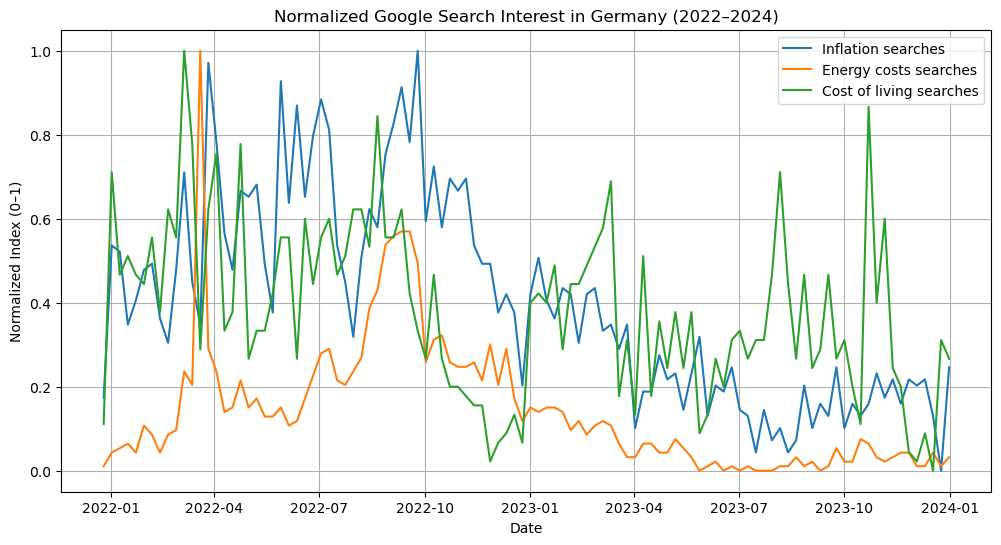

In [27]:

plt.figure(figsize=(12,6))

plt.plot(trends_scaled["date"], trends_scaled["Inflation"], label="Inflation searches")
plt.plot(trends_scaled["date"], trends_scaled["Energiekosten"], label="Energy costs searches")
plt.plot(trends_scaled["date"], trends_scaled["Lebenshaltungskosten"], label="Cost of living searches")

plt.legend()
plt.title("Normalized Google Search Interest in Germany (2022–2024)")
plt.xlabel("Date")
plt.ylabel("Normalized Index (0–1)")
plt.grid(True)

plt.show()

In [29]:
df_inflation["month"] = pd.to_datetime(df_inflation["month"])

trends_monthly["month"] = trends_monthly["month"].dt.to_timestamp()

rates_and_searches = pd.merge(
    df_2024_2025,
    trends_monthly,
    on="month",
    how="inner"
)

rates_and_searches

,month,inflation_rate,Inflation,Energiekosten,Lebenshaltungskosten
0,2022-01-01,5.1,62.60,12.80,78.40
1,2022-02-01,5.5,59.25,14.25,78.75
2,2022-03-01,7.6,73.75,47.25,85.25
3,2022-04-01,7.8,74.00,24.25,80.25
4,2022-05-01,8.7,74.20,20.60,72.20
5,2022-06-01,8.2,82.00,21.50,76.00
6,2022-07-01,8.5,72.40,29.80,79.80
7,2022-08-01,8.8,73.50,44.75,83.75
8,2022-09-01,10.9,91.75,58.00,76.75
9,2022-10-01,11.6,76.00,33.00,67.60


In [ ]:

API_KEY = "f594fecb9eec968ed0337cfe19b5c18c"
BASE_URL = "https://gnews.io/api/v4/search"

QUERY = "inflation OR Teuerung"
COUNTRY = "de"
LANG = "de"

start = datetime(2022, 1, 1)
end   = datetime(2025, 1, 1)  

rows = []
cur = start

while cur < end:
    nxt = cur + relativedelta(months=1)

    params = {
        "q": QUERY,
        "country": COUNTRY,
        "lang": LANG,
        # ISO 8601 mit Z (wichtig!)
        "from": cur.strftime("%Y-%m-%dT00:00:00Z"),
        "to":   (nxt - relativedelta(days=1)).strftime("%Y-%m-%dT23:59:59Z"),
        "max": 1,      # nur 1 Artikel; wir nutzen totalArticles als Count
        "page": 1,
        "apikey": API_KEY
    }

    r = requests.get(BASE_URL, params=params, timeout=30)

    if r.status_code == 429:
        print("429 -> warte 60s und versuche den Monat nochmal:", cur.strftime("%Y-%m"))
        time.sleep(60)
        continue

    r.raise_for_status()
    data = r.json()

    total = data.get("totalArticles")
    print("OK", cur.strftime("%Y-%m"), "from/to:", params["from"], params["to"], "news_count:", total)

    rows.append({"month": cur.strftime("%Y-%m-01"), "news_count": total})

    cur = nxt
    time.sleep(1.2)  # GNews: i.d.R. max ~1 request/sec im Free Plan

news_monthly = pd.DataFrame(rows)
news_monthly["month"] = pd.to_datetime(news_monthly["month"])
news_monthly.head()

OK 2022-01 from/to: 2022-01-01T00:00:00Z 2022-01-31T23:59:59Z news_count: 312
OK 2022-02 from/to: 2022-02-01T00:00:00Z 2022-02-28T23:59:59Z news_count: 267
OK 2022-03 from/to: 2022-03-01T00:00:00Z 2022-03-31T23:59:59Z news_count: 331
OK 2022-04 from/to: 2022-04-01T00:00:00Z 2022-04-30T23:59:59Z news_count: 372
OK 2022-05 from/to: 2022-05-01T00:00:00Z 2022-05-31T23:59:59Z news_count: 566
OK 2022-06 from/to: 2022-06-01T00:00:00Z 2022-06-30T23:59:59Z news_count: 729
OK 2022-07 from/to: 2022-07-01T00:00:00Z 2022-07-31T23:59:59Z news_count: 722
OK 2022-08 from/to: 2022-08-01T00:00:00Z 2022-08-31T23:59:59Z news_count: 649
OK 2022-09 from/to: 2022-09-01T00:00:00Z 2022-09-30T23:59:59Z news_count: 777
OK 2022-10 from/to: 2022-10-01T00:00:00Z 2022-10-31T23:59:59Z news_count: 682
OK 2022-11 from/to: 2022-11-01T00:00:00Z 2022-11-30T23:59:59Z news_count: 733
OK 2022-12 from/to: 2022-12-01T00:00:00Z 2022-12-31T23:59:59Z news_count: 524
OK 2023-01 from/to: 2023-01-01T00:00:00Z 2023-01-31T23:59:59Z ne

,month,news_count
0,2022-01-01,312
1,2022-02-01,267
2,2022-03-01,331
3,2022-04-01,372
4,2022-05-01,566


In [14]:
news_monthly.to_csv("../data/processed/news_monthly.csv", index=False)

In [32]:

rates_and_searches["month"] = pd.to_datetime(rates_and_searches["month"]).dt.to_period("M").dt.to_timestamp()
news_monthly["month"] = pd.to_datetime(news_monthly["month"]).dt.to_period("M").dt.to_timestamp()

In [33]:
final_data = rates_and_searches.merge(news_monthly, on="month", how="inner")
final_data

,month,inflation_rate,Inflation,Energiekosten,Lebenshaltungskosten,news_count
0,2022-01-01,5.1,62.60,12.80,78.40,312
1,2022-02-01,5.5,59.25,14.25,78.75,267
2,2022-03-01,7.6,73.75,47.25,85.25,331
3,2022-04-01,7.8,74.00,24.25,80.25,372
4,2022-05-01,8.7,74.20,20.60,72.20,566
5,2022-06-01,8.2,82.00,21.50,76.00,729
6,2022-07-01,8.5,72.40,29.80,79.80,722
7,2022-08-01,8.8,73.50,44.75,83.75,649
8,2022-09-01,10.9,91.75,58.00,76.75,777
9,2022-10-01,11.6,76.00,33.00,67.60,682


In [ ]:
final_data.to_csv("data/processed/final_dataset.csv", index=False)

In [34]:
import requests
import pandas as pd
from itertools import product


def fetch_eurostat_data(url, value_name):
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    ids = data["id"]                      # Reihenfolge der Dimensionen
    sizes = data["size"]                  # Länge je Dimension
    values = data["value"]                # Beobachtungen
    dimensions = data["dimension"]

    # Labels je Dimension vorbereiten, sortiert nach ihrem Index
    dim_labels = {}
    for dim in ids:
        cat_index = dimensions[dim]["category"]["index"]
        sorted_labels = [label for label, _ in sorted(cat_index.items(), key=lambda x: x[1])]
        dim_labels[dim] = sorted_labels

    # Alle möglichen Kombinationen der Dimensionspositionen
    all_positions = list(product(*[range(s) for s in sizes]))

    rows = []
    for flat_idx_str, val in values.items():
        flat_idx = int(flat_idx_str)
        pos_tuple = all_positions[flat_idx]

        row = {}
        for dim_name, pos in zip(ids, pos_tuple):
            row[dim_name] = dim_labels[dim_name][pos]

        row[value_name] = val
        rows.append(row)

    df = pd.DataFrame(rows)

    # Zeitspalte umwandeln
    if "time" in df.columns:
        df["time"] = pd.PeriodIndex(df["time"], freq="M").to_timestamp()

    return df


energy_url = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "prc_hicp_midx?geo=DE&coicop=CP045&unit=I15&sinceTimePeriod=2022&untilTimePeriod=2024"
)

food_url = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "prc_hicp_midx?geo=DE&coicop=CP01&unit=I15&sinceTimePeriod=2022&untilTimePeriod=2024"
)

labour_url = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "une_rt_m?geo=DE&sinceTimePeriod=2022&untilTimePeriod=2024"
)

df_energy = fetch_eurostat_data(energy_url, "energy_price_index")
df_food = fetch_eurostat_data(food_url, "food_price_index")
df_labour = fetch_eurostat_data(labour_url, "unemployment_rate")

print("ENERGY")
print(df_energy.head(), "\n")

print("FOOD")
print(df_food.head(), "\n")

print("LABOUR")
print(df_labour.head(), "\n")

ENERGY
  freq unit coicop geo       time  energy_price_index
0    M  I15  CP045  DE 2022-01-01               121.5
1    M  I15  CP045  DE 2022-02-01               124.7
2    M  I15  CP045  DE 2022-03-01               137.9
3    M  I15  CP045  DE 2022-04-01               137.3
4    M  I15  CP045  DE 2022-05-01               141.2 

FOOD
  freq unit coicop geo       time  food_price_index
0    M  I15   CP01  DE 2022-01-01             116.8
1    M  I15   CP01  DE 2022-02-01             118.0
2    M  I15   CP01  DE 2022-03-01             119.0
3    M  I15   CP01  DE 2022-04-01             122.8
4    M  I15   CP01  DE 2022-05-01             125.2 

LABOUR
  freq s_adj    age    unit sex geo       time  unemployment_rate
0    M   NSA  TOTAL  PC_ACT   F  DE 2022-01-01                3.1
1    M   NSA  TOTAL  PC_ACT   F  DE 2022-02-01                2.8
2    M   NSA  TOTAL  PC_ACT   F  DE 2022-03-01                2.7
3    M   NSA  TOTAL  PC_ACT   F  DE 2022-04-01                3.1
4    M   NS

In [36]:
df_labour.to_csv("data/raw/unemployment_rate_2022_2024.csv", index=False)

In [ ]:
df_energy.to_csv("data/raw/ernergy_cost.csv", index=False)


In [ ]:
df_food.to_csv("data/raw/fooprice_index.csv", index=False)


In [37]:
df_labour_filtered = df_labour[
    (df_labour["s_adj"]=="SA")&
    (df_labour["unit"]=="PC_ACT")&
    (df_labour["age"]=="TOTAL")&
    (df_labour["sex"]=="T")
]
df_labour_filtered

,freq,s_adj,age,unit,sex,geo,time,unemployment_rate
720,M,SA,TOTAL,PC_ACT,T,DE,2022-01-01,3.3
721,M,SA,TOTAL,PC_ACT,T,DE,2022-02-01,3.2
722,M,SA,TOTAL,PC_ACT,T,DE,2022-03-01,3.2
723,M,SA,TOTAL,PC_ACT,T,DE,2022-04-01,3.1
724,M,SA,TOTAL,PC_ACT,T,DE,2022-05-01,3.1
725,M,SA,TOTAL,PC_ACT,T,DE,2022-06-01,3.1
726,M,SA,TOTAL,PC_ACT,T,DE,2022-07-01,3.1
727,M,SA,TOTAL,PC_ACT,T,DE,2022-08-01,3.1
728,M,SA,TOTAL,PC_ACT,T,DE,2022-09-01,3.2
729,M,SA,TOTAL,PC_ACT,T,DE,2022-10-01,3.1


In [52]:
df_labour_filtered = df_labour_filtered.drop(["freq", "s_adj", "age", "unit", "sex", "geo"], axis=1)

KeyError: "['freq', 's_adj', 'age', 'unit', 'sex', 'geo'] not found in axis"

In [65]:
df_labour_filtered.columns

Index(['time', 'unemployment_rate'], dtype='object')

In [66]:
df_food.columns
df_food = df_food.drop(["freq", "unit", "coicop", "geo"], axis=1)
df_energy

KeyError: "['freq', 'unit', 'coicop', 'geo'] not found in axis"

In [63]:
df_energy.columns
df_energy = df_energy.drop(["freq", "unit", "coicop", "geo"], axis=1)
df_energy

,time,energy_price_index
0,2022-01-01,121.5
1,2022-02-01,124.7
2,2022-03-01,137.9
3,2022-04-01,137.3
4,2022-05-01,141.2
5,2022-06-01,145.6
6,2022-07-01,149.3
7,2022-08-01,153.4
8,2022-09-01,160.4
9,2022-10-01,169.2


In [67]:
df_labour_filtered = df_labour_filtered.reset_index(drop=True)

In [ ]:
'''df_energy.to_csv('energy.csv')
df_food.to_csv('food.csv') 
df_labour_filtered.to_csv('labour.csv')
df_2024_2025.to_csv('inflation.csv') 
news_monthly.to_csv('news_monthly.csv')
trends_monthly.to_csv('trends_monthly.csv')'''


In [70]:
df_2024_2025.reset_index(drop=True)

,month,inflation_rate
0,2022-01-01,5.1
1,2022-02-01,5.5
2,2022-03-01,7.6
3,2022-04-01,7.8
4,2022-05-01,8.7
5,2022-06-01,8.2
6,2022-07-01,8.5
7,2022-08-01,8.8
8,2022-09-01,10.9
9,2022-10-01,11.6


In [ ]:
'''trends_monthly.to_csv("../data/processed/trends_monthly.csv", index=False)'''